In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Airline_Delay_Cause.csv to Airline_Delay_Cause.csv


In [4]:
df = pd.read_csv('Airline_Delay_Cause.csv')

In [5]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  object 
 3   carrier_name         171666 non-null  object 
 4   airport              171666 non-null  object 
 5   airport_name         171666 non-null  object 
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay        

In [7]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
carrier_name,0
airport,0
airport_name,0
arr_flights,240
arr_del15,443
carrier_ct,240
weather_ct,240


In [8]:
df = df.dropna()

In [10]:
df.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [12]:
df.columns.tolist()

['year',
 'month',
 'carrier',
 'carrier_name',
 'airport',
 'airport_name',
 'arr_flights',
 'arr_del15',
 'carrier_ct',
 'weather_ct',
 'nas_ct',
 'security_ct',
 'late_aircraft_ct',
 'arr_cancelled',
 'arr_diverted',
 'arr_delay',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay']

In [13]:
airport_delay = df.groupby('airport_name')['arr_delay'].mean().sort_values(ascending=False)

print(airport_delay.head(10))

airport_name
Chicago, IL: Chicago O'Hare International                 28708.522325
Dallas/Fort Worth, TX: Dallas/Fort Worth International    26532.661808
Atlanta, GA: Hartsfield-Jackson Atlanta International     23149.151656
Denver, CO: Denver International                          21693.583269
San Francisco, CA: San Francisco International            19627.079536
Las Vegas, NV: Harry Reid International                   18241.174721
New York, NY: John F. Kennedy International               18037.234984
Sanford, FL: Orlando Sanford International                17022.191176
Los Angeles, CA: Los Angeles International                17013.331395
Newark, NJ: Newark Liberty International                  16330.681193
Name: arr_delay, dtype: float64


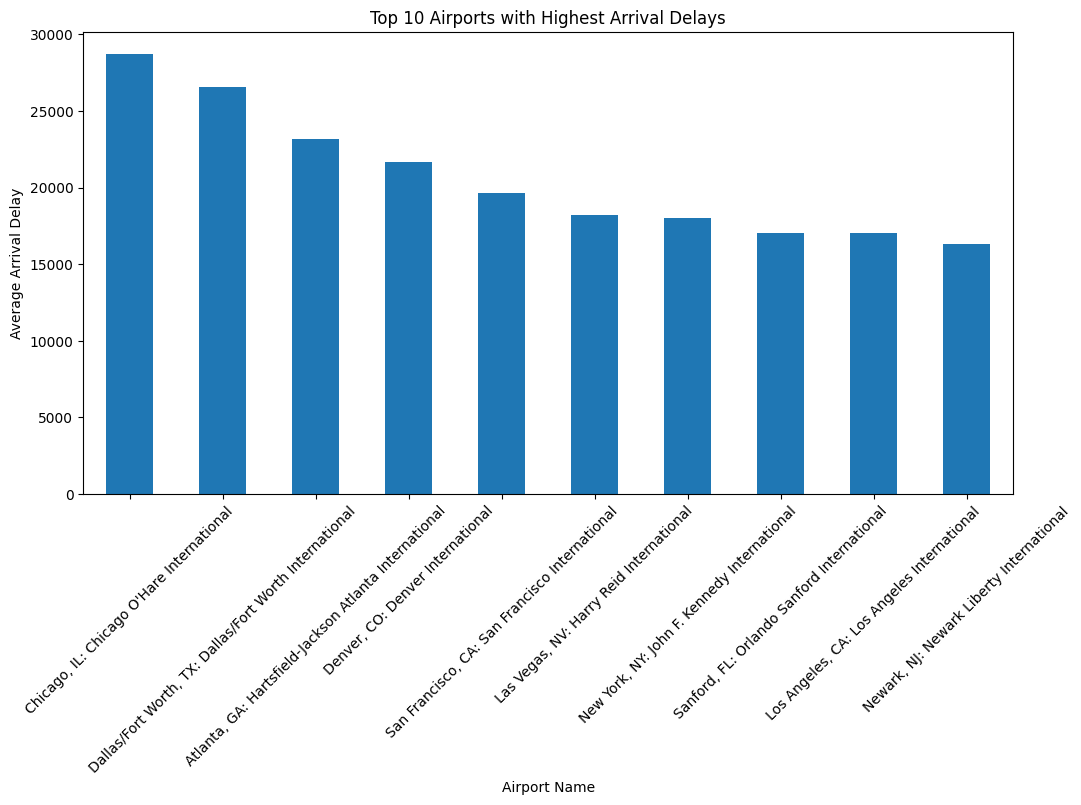

In [14]:
plt.figure(figsize=(12,6))

airport_delay.head(10).plot(kind='bar')

plt.title('Top 10 Airports with Highest Arrival Delays')
plt.xlabel('Airport Name')
plt.ylabel('Average Arrival Delay')

plt.xticks(rotation=45)

plt.show()

In [15]:
weather_impact = df.groupby('airport_name')['weather_delay'].mean().sort_values(ascending=False)

print(weather_impact.head(10))

airport_name
Dallas/Fort Worth, TX: Dallas/Fort Worth International    1750.375364
Chicago, IL: Chicago O'Hare International                 1506.315379
Atlanta, GA: Hartsfield-Jackson Atlanta International     1193.520530
Sanford, FL: Orlando Sanford International                1103.544118
Denver, CO: Denver International                          1062.571650
Aspen, CO: Aspen Pitkin County Sardy Field                 943.690647
St. Petersburg, FL: St Pete Clearwater International       906.220588
Houston, TX: George Bush Intercontinental/Houston          801.391987
Minneapolis, MN: Minneapolis-St Paul International         790.118439
Chicago, IL: Chicago Midway International                  777.357708
Name: weather_delay, dtype: float64


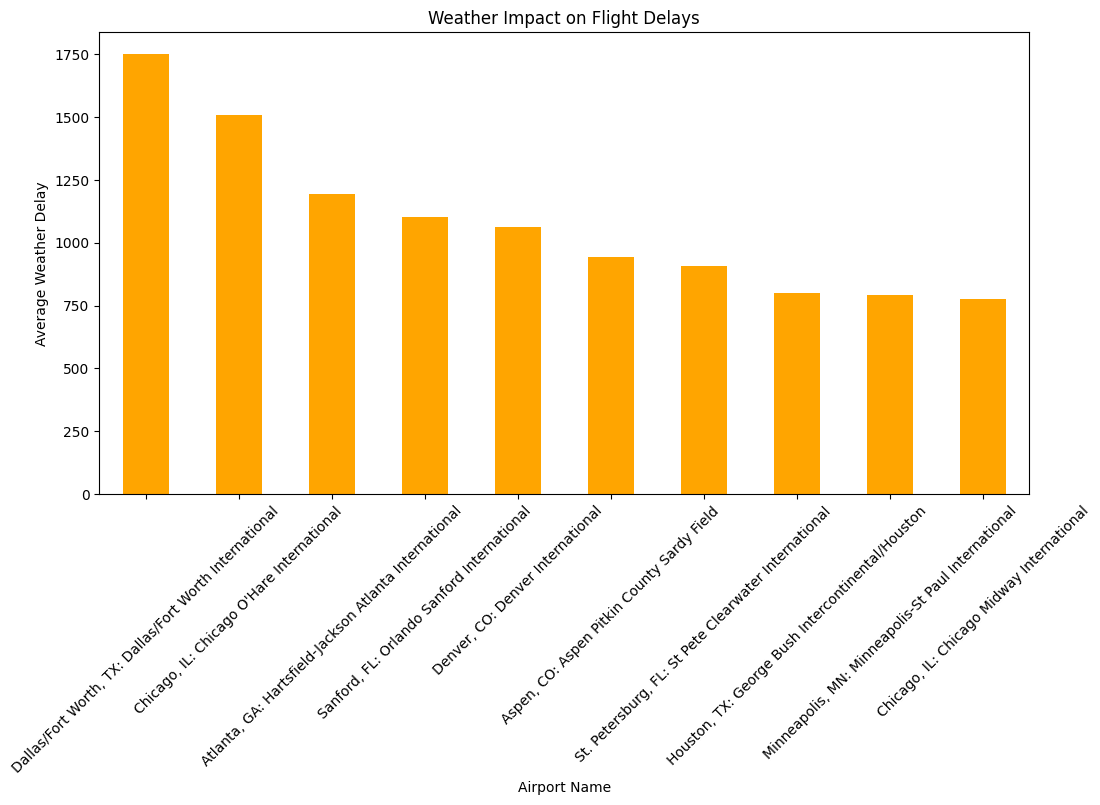

In [16]:
plt.figure(figsize=(12,6))

weather_impact.head(10).plot(kind='bar', color='orange')

plt.title('Weather Impact on Flight Delays')
plt.xlabel('Airport Name')
plt.ylabel('Average Weather Delay')

plt.xticks(rotation=45)

plt.show()

In [17]:
monthly_delay = df.groupby('month')['arr_delay'].mean()

print(monthly_delay)

month
1     4141.529858
2     3877.282893
3     3927.126430
4     3874.963664
5     4147.566861
6     5582.427243
7     5911.601044
8     5098.397868
9     3002.961101
10    3313.924826
11    3126.780969
12    4790.016046
Name: arr_delay, dtype: float64


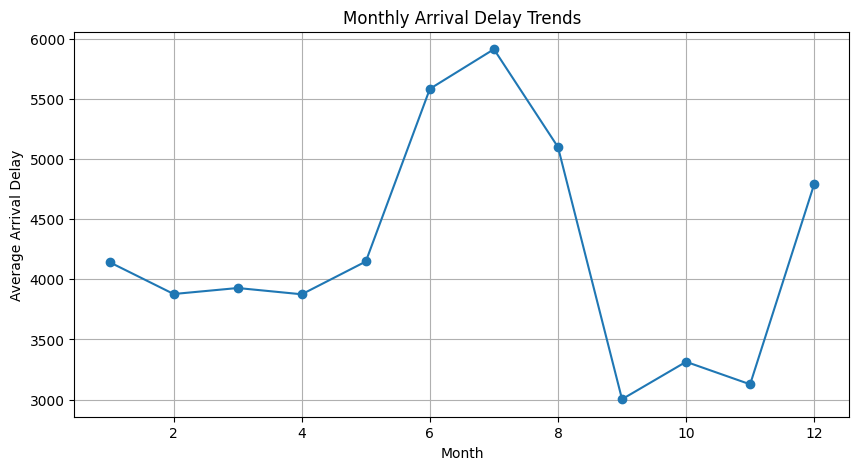

In [18]:
plt.figure(figsize=(10,5))

monthly_delay.plot(kind='line', marker='o')

plt.title('Monthly Arrival Delay Trends')
plt.xlabel('Month')
plt.ylabel('Average Arrival Delay')

plt.grid(True)

plt.show()

In [19]:
delay_types = df[['carrier_delay',
                  'weather_delay',
                  'nas_delay',
                  'security_delay',
                  'late_aircraft_delay']].mean()

print(delay_types)

carrier_delay          1438.889034
weather_delay           222.827365
nas_delay               921.743218
security_delay            7.391478
late_aircraft_delay    1653.658299
dtype: float64


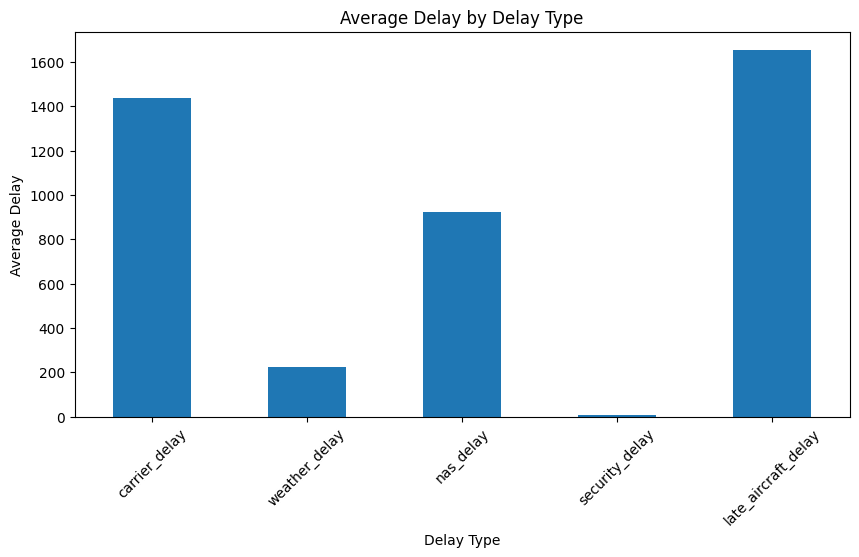

In [20]:
plt.figure(figsize=(10,5))

delay_types.plot(kind='bar')

plt.title('Average Delay by Delay Type')
plt.xlabel('Delay Type')
plt.ylabel('Average Delay')

plt.xticks(rotation=45)

plt.show()